In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [11]:
model_path = "frozen_inference_graph.pb"
config_path = "ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt"
classes_path="coco.names"

In [12]:
print("Current Working Directory:", os.getcwd())
print("model Dosyası Var mı?:", os.path.exists(model_path))
print("class Dosyası Var mı?:", os.path.exists(classes_path))
print("image Var mı?:", os.path.exists(classes_path))

Current Working Directory: C:\Users\Monster\OneDrive\Masaüstü\opencv-dnn-models\4
model Dosyası Var mı?: True
class Dosyası Var mı?: True
image Var mı?: True


In [ ]:
classes = []
with open(classes_path, "r") as f:
    classes = f.read().strip().split("\n")

In [ ]:
net = cv2.dnn.readNetFromTensorflow(model_path,config_path)

In [ ]:
image = cv2.imread("car.jpg")
(h, w) = image.shape[:2]

In [ ]:
blob = cv2.dnn.blobFromImage(
    image,
    scalefactor=1/255.0,
    size=(320, 320),   # SSD v3 Large için genelde 320x320
    swapRB=True,
    crop=False
)

In [ ]:

net.setInput(blob)
detections = net.forward()


In [ ]:
conf_threshold = 0.5
nms_threshold = 0.4

In [ ]:
boxes, confidences, class_ids = [], [], []

In [ ]:
for detection in detections[0, 0, :, :]:
    confidence = float(detection[2])
    if confidence > conf_threshold:
        class_id = int(detection[1])
        x1 = int(detection[3] * w)
        y1 = int(detection[4] * h)
        x2 = int(detection[5] * w)
        y2 = int(detection[6] * h)

        boxes.append([x1, y1, x2 - x1, y2 - y1])
        confidences.append(confidence)
        class_ids.append(class_id)

In [ ]:
# NMS uygula
indices = cv2.dnn.NMSBoxes(boxes, confidences, conf_threshold, nms_threshold)

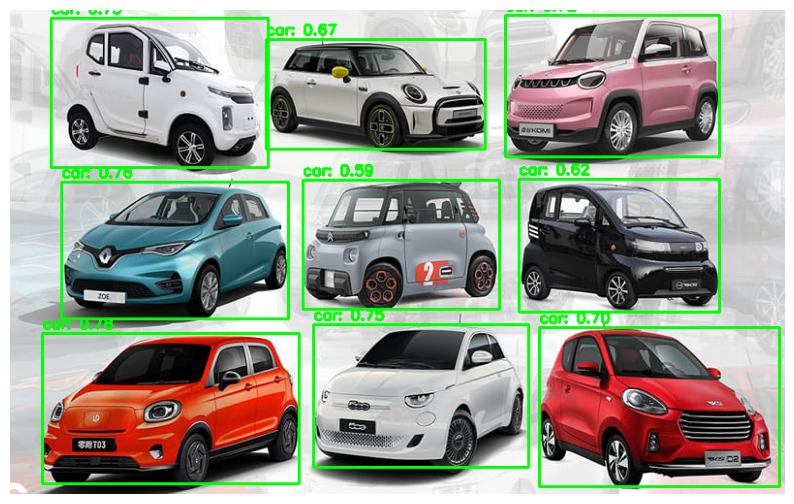

In [9]:
# --- Sonuçları çiz ---
for i in indices.flatten():
    x, y, bw, bh = boxes[i]
    label = classes[class_ids[i] - 1] if 0 < class_ids[i] <= len(classes) else f"Class {class_ids[i]}"
    conf = confidences[i]

    cv2.rectangle(image, (x, y), (x + bw, y + bh), (0, 255, 0), 2)
    cv2.putText(image, f"{label}: {conf:.2f}", (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Görüntüyü göster
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()